# PCA Visualization of BrainIAC Features

This notebook loads a features CSV (rows = scans, columns = Feature_0...Feature_767 and a label column), performs PCA on the latent features, and visualizes results: scree plot, 2D/3D scatter of samples in PC space, and top contributing features per principal component.

How to use:
- Set the `csv_path` variable in the first code cell to point to your features CSV.
- Set `n_components` for PCA and `top_k` to show top contributing features.
- Run all cells.


### Config

In [7]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display
sns.set(style='whitegrid', context='notebook')


In [8]:
# Parameters
csv_path = 'features.csv'  # path to your features CSV
n_components = 10  # how many principal components to compute/plot
top_k = 10  # top contributing features to show for each principal component
sample_for_pairplot = 1000  # if dataset is large, sample this many rows for pairplot (None to use all)
show_3d = True  # whether to show 3D scatter if n_components >= 3
output_reduced_csv = 'features_pca.csv'  # optional: save the PCA-transformed data
medical_info_path = 'participants.tsv'


### Load Features

In [9]:
# Load CSV and detect feature columns
df = pd.read_csv(csv_path)[6:-1]
print('Loaded', csv_path, 'with shape', df.shape)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]
print('Found feature columns:', len(feature_cols))
if not feature_cols:
    # fallback: assume all columns except last are features
    feature_cols = df.columns[:-1].tolist()
    print('Falling back to all columns except last as features. Using', len(feature_cols), 'features.')
# detect label column if present
non_feature_cols = [c for c in df.columns if c not in feature_cols]
label_col = None
if non_feature_cols:
    # if exactly one non-feature column, choose it; else look for 'GroundTruthClassLabel' or 'label'
    if len(non_feature_cols) == 1:
        label_col = non_feature_cols[0]
    else:
        for candidate in ['GroundTruthClassLabel', 'label', 'Label', 'class', 'Class']:
            if candidate in df.columns:
                label_col = candidate
                break
print('Using label column:', label_col)
X = df[feature_cols].values.astype(float)
print('Feature matrix shape:', X.shape)


Loaded features.csv with shape (20, 769)
Found feature columns: 768
Using label column: GroundTruthClassLabel
Feature matrix shape: (20, 768)


In [10]:
# Load participants table and extract gestation_week
participants = pd.read_csv(medical_info_path, sep='\t')[6:-1]
display(participants)
# Parse gestation_week into numeric values where possible
if 'gestation_week' in participants.columns:
    gw_series = participants['gestation_week'].astype(str).str.strip()
    gw_series = gw_series.replace({'n/a': '', 'N/A': '', 'NaN': '', 'nan': ''})
    participants_gw = pd.to_numeric(gw_series.replace('', pd.NA), errors='coerce')
    print('Parsed gestation_week (first 10):')
    print(participants_gw.head(10))
else:
    print('gestation_week column not found in', medical_info_path)


,group,participant_id,session_id,scanning_site,scan_date(mm/dd/year),scan_time_start,has_T1w,has_hippocampus_T2w,has_fmaps,has_DWI,...,psqi,pss,stai,poms_tension,poms_depression,poms_anger,poms_fatigue,poms_confusion,poms_vigor,poms_total_mood
6,MBP-Pilot,sub-01,ses-07,UCI,10/10/2019,11:34am,1,1,0.5,1,...,3.0,11.0,37.0,6.0,3.0,4.0,14.0,4.0,19.0,12.0
7,MBP-Pilot,sub-01,ses-08,UCI,10/25/2019,1:10pm,1,1,1.0,1,...,3.0,11.0,30.0,4.0,2.0,1.0,7.0,2.0,19.0,-3.0
8,MBP-Pilot,sub-01,ses-09,UCI,11/12/2019,9am,1,1,1.0,0,...,4.0,10.0,33.0,5.0,1.0,2.0,13.0,5.0,17.0,9.0
9,MBP-Pilot,sub-01,ses-10,UCI,11/18/2019,9:30am,1,1,1.0,1,...,2.0,13.0,36.0,8.0,1.0,1.0,8.0,4.0,21.0,1.0
10,MBP-Pilot,sub-01,ses-11,UCI,12/3/2019,3:21pm,1,1,1.0,1,...,3.0,13.0,30.0,5.0,3.0,0.0,11.0,3.0,11.0,11.0
11,MBP-Pilot,sub-01,ses-12,UCI,12/17/2019,9:45am,1,1,1.0,1,...,4.0,10.0,40.0,13.0,4.0,3.0,9.0,7.0,17.0,19.0
12,MBP-Pilot,sub-01,ses-13,UCI,1/7/2020,9:39am,1,1,1.0,1,...,5.0,12.0,32.0,5.0,4.0,0.0,10.0,5.0,16.0,8.0
13,MBP-Pilot,sub-01,ses-14,UCI,1/22/2020,9:35am,1,1,1.0,1,...,2.0,9.0,32.0,6.0,2.0,0.0,7.0,3.0,18.0,0.0
14,MBP-Pilot,sub-01,ses-15,UCI,02/07/2020,9:42am,1,0,1.0,0,...,2.0,11.0,32.0,6.0,1.0,0.0,4.0,3.0,21.0,-7.0
15,MBP-Pilot,sub-01,ses-16,UCI,02/24/2020,4:30pm,1,1,1.0,1,...,7.0,10.0,36.0,9.0,5.0,5.0,14.0,3.0,13.0,23.0


Parsed gestation_week (first 10):
6      9.0
7     12.0
8     14.0
9     15.0
10    17.0
11    19.0
12    22.0
13    24.0
14    27.0
15    29.0
Name: gestation_week, dtype: float64


In [11]:
# Standardize and run PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
pc_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
# Prefer gestation_week from participants.tsv if available and matching length
plot_label_name = None
if 'participants_gw' in globals():
    try:
        if len(participants_gw) == len(df):
            df_pca['gestation_week'] = participants_gw.values
            plot_label_name = 'gestation_week'
        else:
            print(f'participants_gw length ({len(participants_gw)}) != number of samples ({len(df)}); ignoring participants_gw')
    except Exception as e:
        print('Error using participants_gw:', e)
# Fallback to label column detected in features CSV
if plot_label_name is None:
    if label_col:
        try:
            df_pca[label_col] = df[label_col].values
            plot_label_name = label_col
        except Exception as e:
            print('Failed to use existing label_col:', e)
# expose chosen label name to subsequent cells
label_col = plot_label_name
print('Using label for plotting:', label_col)
print('PCA done. Explained variance ratios:', pca.explained_variance_ratio_)


Using label for plotting: gestation_week
PCA done. Explained variance ratios: [0.37649918 0.20999912 0.132076   0.09751579 0.04461762 0.03149769
 0.02371807 0.02059978 0.01511092 0.01303476]


## Best matching pairs from PC1-PC3

In [21]:
import numpy as np
import pandas as pd

# -----------------------------------
# Use first 3 PCs
# -----------------------------------
pc_cols_3 = ['PC1', 'PC2', 'PC3']
if not all(c in df_pca.columns for c in pc_cols_3):
    raise ValueError("Need PC1, PC2, PC3 in df_pca.")

P = df_pca[pc_cols_3].values  # shape: (n_samples, 3)

# Unit vectors along PC axes
u_pc1 = np.array([1.0, 0.0, 0.0])
u_pc2 = np.array([0.0, 1.0, 0.0])
u_pc3 = np.array([0.0, 0.0, 1.0])

unit_vectors = {
    "PC1": u_pc1,
    "PC2": u_pc2,
    "PC3": u_pc3
}

# Optional: create labels for rows
sample_ids = df_pca.index.to_numpy()

# -----------------------------------
# Find pair with maximum projection
# -----------------------------------
def find_max_inner_product_pair(P, u):
    """
    Find pair (i, j) maximizing <u, p_i - p_j>.
    Equivalent to maximizing the scalar projection difference along u.
    """
    scores = P @ u  # projection of each sample onto u
    # max <u, p_i - p_j> = max(scores[i] - scores[j])
    i = np.argmax(scores)
    j = np.argmin(scores)
    max_val = scores[i] - scores[j]
    return i, j, max_val, scores

results = []

for pc_name, u in unit_vectors.items():
    i, j, max_val, scores = find_max_inner_product_pair(P, u)

    result = {
        "pc_dim": pc_name,
        "sample_i": sample_ids[i],
        "sample_j": sample_ids[j],
        "max_inner_product": max_val,
        "proj_i": scores[i],
        "proj_j": scores[j],
        "PC1_i": P[i, 0], "PC2_i": P[i, 1], "PC3_i": P[i, 2],
        "PC1_j": P[j, 0], "PC2_j": P[j, 1], "PC3_j": P[j, 2],
    }

    if 'gestation_week' in df_pca.columns:
        result["gestation_week_i"] = df_pca.iloc[i]['gestation_week']
        result["gestation_week_j"] = df_pca.iloc[j]['gestation_week']

    results.append(result)

    print(f"\n=== {pc_name} ===")
    print(f"Sample i: {i}, Sample j: {j}")
    print(f"Max <u_{pc_name}, p_i - p_j> = {max_val:.4f}")
    if 'gestation_week' in df_pca.columns:
        print(f"gestation_week_i = {result['gestation_week_i']}, gestation_week_j = {result['gestation_week_j']}")

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df)


=== PC1 ===
Sample i: 2, Sample j: 12
Max <u_PC1, p_i - p_j> = 74.7833
gestation_week_i = 14.0, gestation_week_j = 36.0

=== PC2 ===
Sample i: 9, Sample j: 14
Max <u_PC2, p_i - p_j> = 50.2908
gestation_week_i = 29.0, gestation_week_j = 46.0

=== PC3 ===
Sample i: 11, Sample j: 10
Max <u_PC3, p_i - p_j> = 41.7250
gestation_week_i = 33.0, gestation_week_j = 31.0

Summary:
  pc_dim  sample_i  sample_j  max_inner_product     proj_i     proj_j  \
0    PC1         2        12          74.783270  51.736129 -23.047140   
1    PC2         9        14          50.290760  32.786189 -17.504571   
2    PC3        11        10          41.725029  30.503400 -11.221629   

       PC1_i      PC2_i      PC3_i      PC1_j      PC2_j      PC3_j  \
0  51.736129  10.191339  -2.022224 -23.047140  24.720106  -3.459844   
1 -12.700801  32.786189   1.557024  -9.533074 -17.504571  -6.441367   
2  -3.736870   3.973221  30.503400 -15.296148  -5.053542 -11.221629   

   gestation_week_i  gestation_week_j  
0       

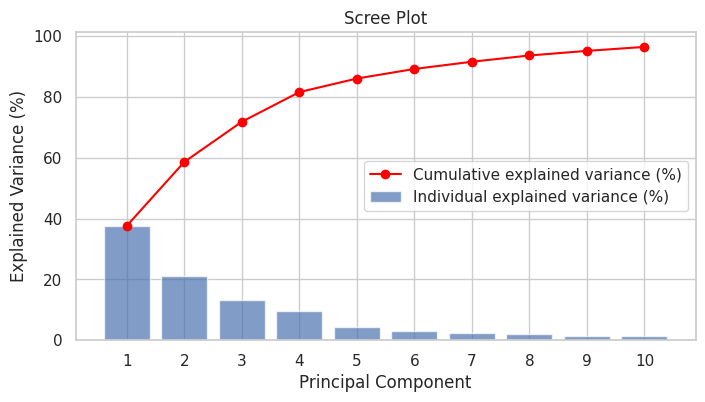

In [22]:
# Scree plot
var_ratio = pca.explained_variance_ratio_
cumvar = np.cumsum(var_ratio)
plt.figure(figsize=(8,4))
plt.bar(range(1, len(var_ratio)+1), var_ratio*100, alpha=0.7, label='Individual explained variance (%)')
plt.plot(range(1, len(var_ratio)+1), cumvar*100, marker='o', color='red', label='Cumulative explained variance (%)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.xticks(range(1, len(var_ratio)+1))
plt.legend()
plt.grid(True)
plt.show()


## Triangular Pairwise Plot for PC1-PC10


/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/tyd

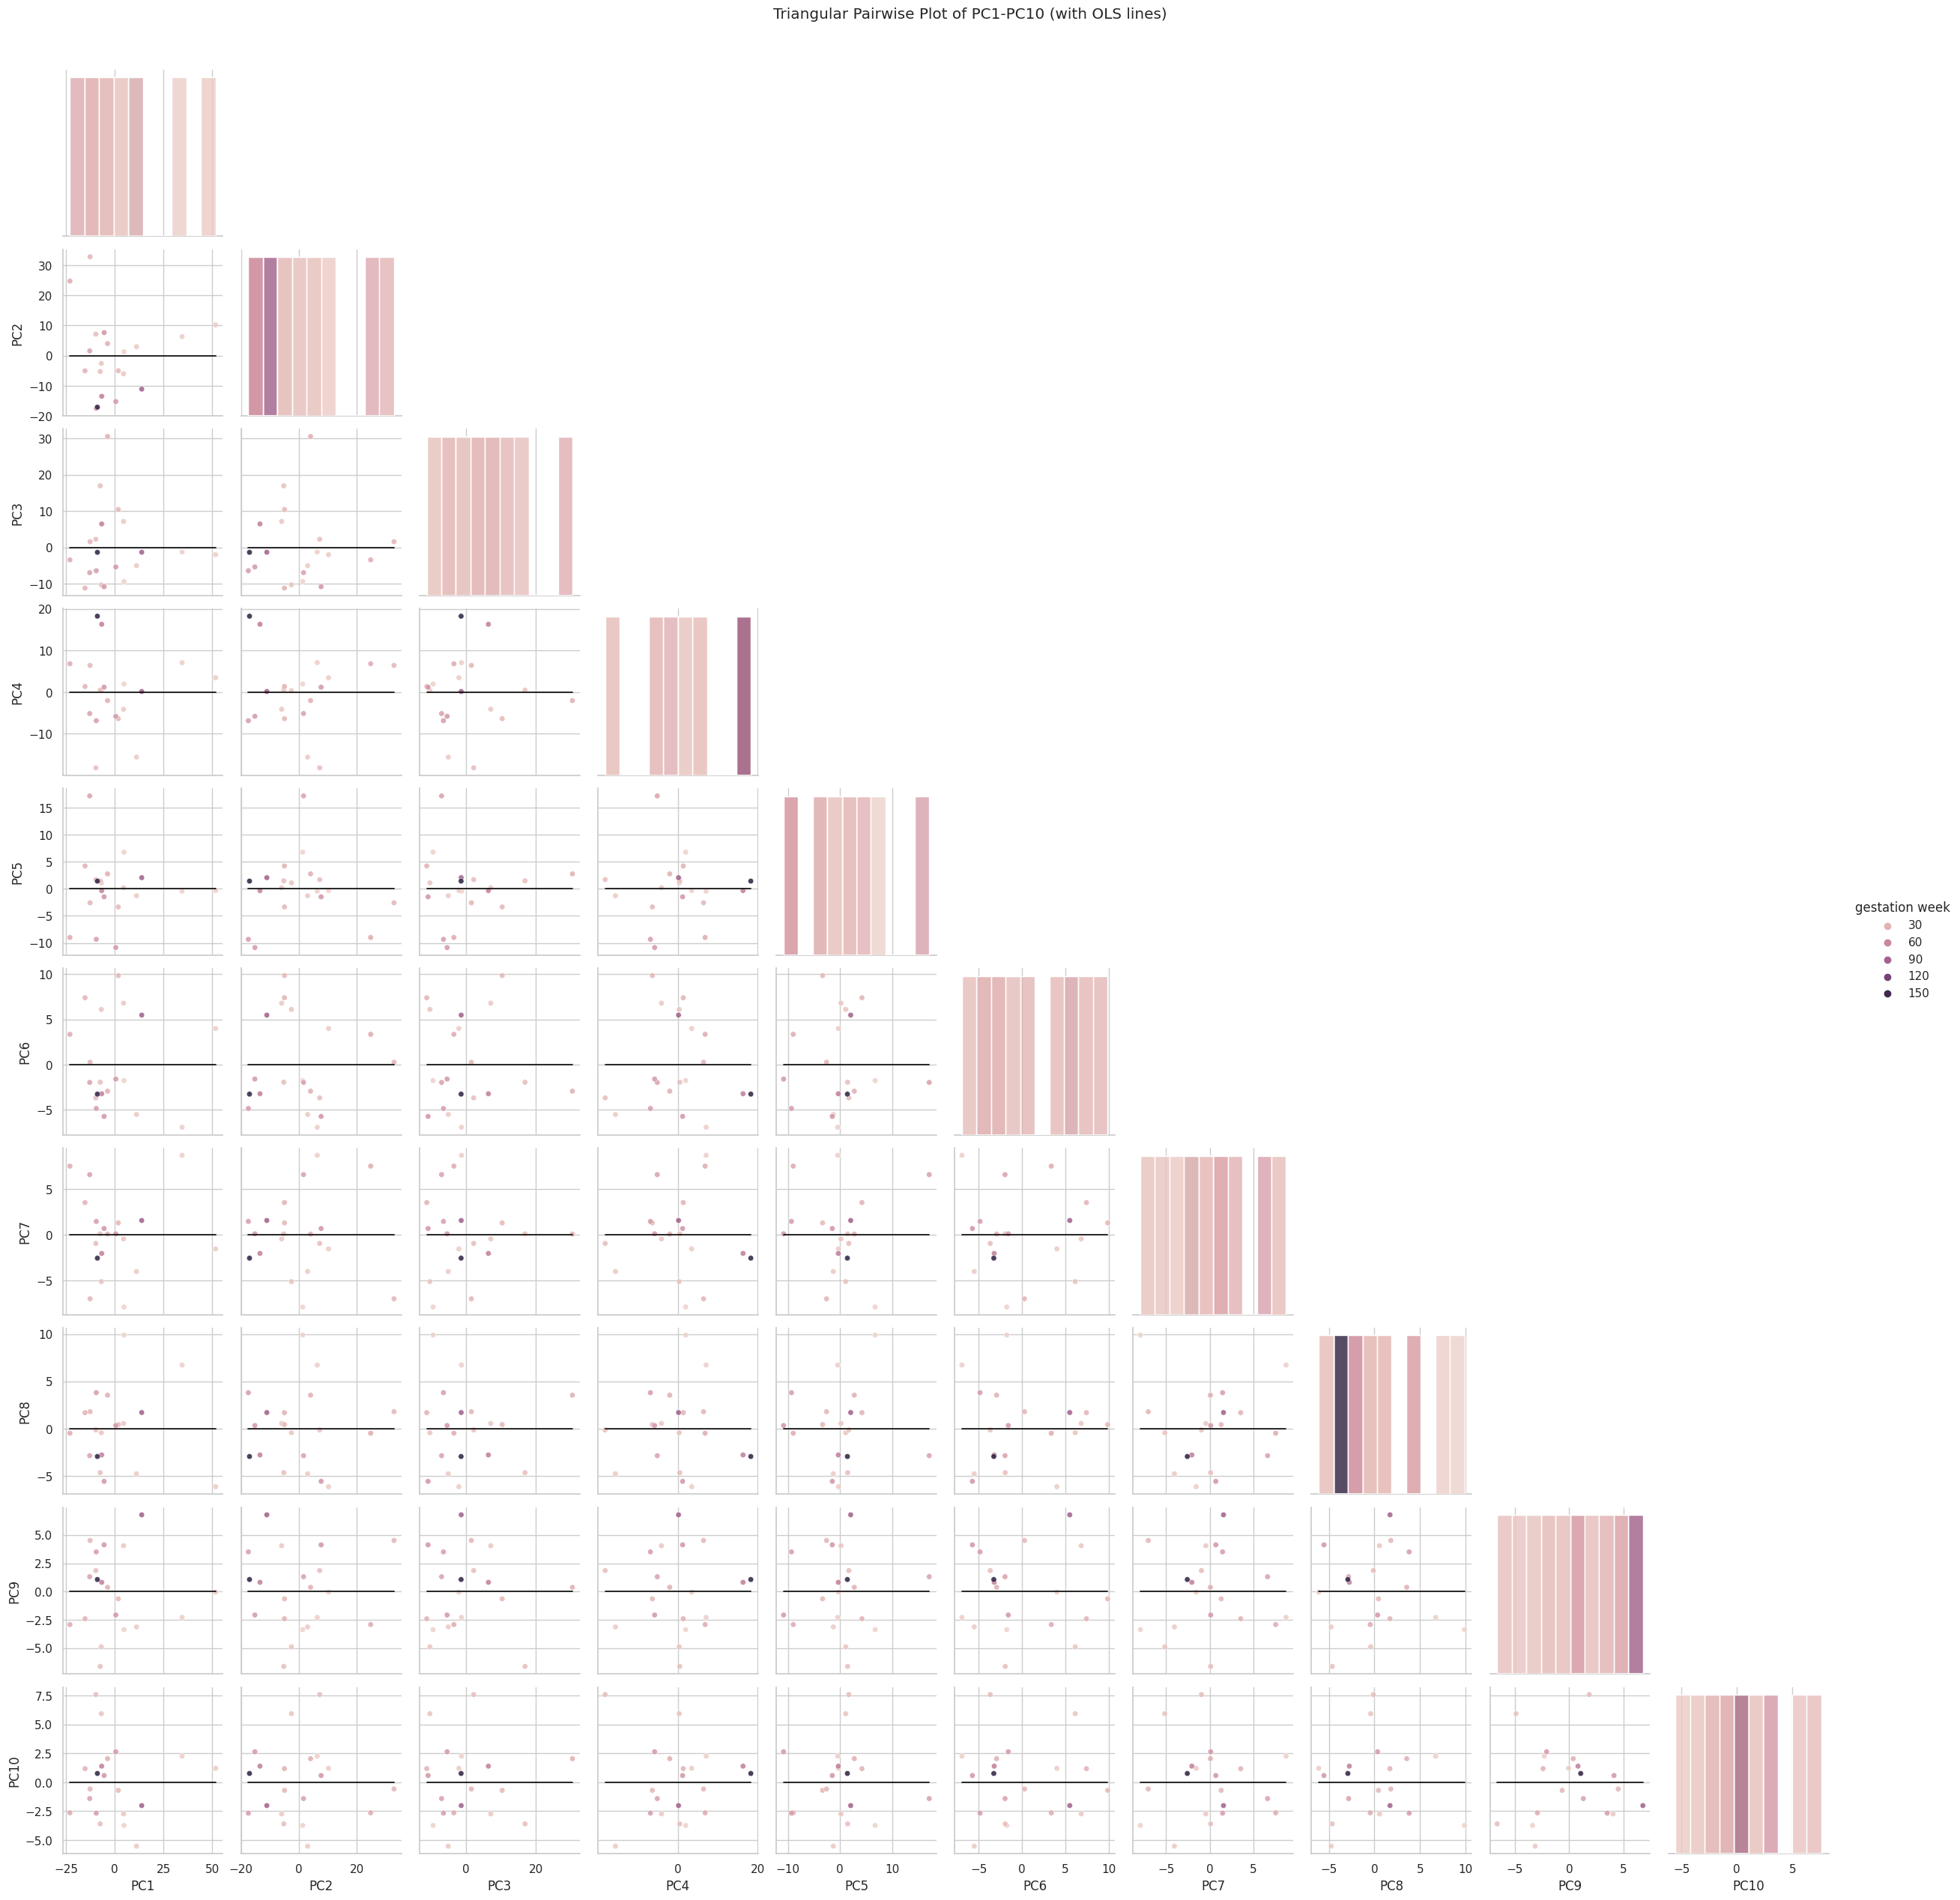

In [12]:
# Triangular pairwise scatter plot for first 10 PCs with OLS overlays
plot_pc_cols = [f'PC{i}' for i in range(1, 11) if f'PC{i}' in df_pca.columns]

if len(plot_pc_cols) < 2:
    raise ValueError('Need at least two principal components for pairwise plotting.')

pair_df = df_pca[plot_pc_cols].copy()

# Optional downsampling for very large datasets
if sample_for_pairplot is not None and len(pair_df) > sample_for_pairplot:
    pair_df = pair_df.sample(sample_for_pairplot, random_state=42)

# If a numeric label is available, color by label; otherwise plain pair plot
hue_col = None
display_hue_col = None
if label_col is not None and label_col in df_pca.columns:
    numeric_label = pd.to_numeric(df_pca[label_col], errors='coerce')
    if numeric_label.notna().all():
        pair_df[label_col] = numeric_label.loc[pair_df.index]
        hue_col = label_col
        display_hue_col = 'gestation week' if label_col == 'gestation_week' else label_col.replace('_', ' ')
        pair_df[display_hue_col] = pair_df[hue_col]

if display_hue_col is not None:
    g = sns.pairplot(
        pair_df,
        vars=plot_pc_cols,
        hue=display_hue_col,
        corner=True,
        diag_kind='hist',
        plot_kws={'s': 28, 'alpha': 0.85},
        diag_kws={'bins': 10, 'alpha': 0.8}
    )
else:
    g = sns.pairplot(
        pair_df,
        vars=plot_pc_cols,
        corner=True,
        diag_kind='hist',
        plot_kws={'s': 28, 'alpha': 0.85},
        diag_kws={'bins': 10, 'alpha': 0.8}
    )

# Overlay OLS lines on each lower-triangle subplot
for i in range(len(plot_pc_cols)):
    for j in range(i):
        ax = g.axes[i, j]
        if ax is None:
            continue
        sns.regplot(
            data=pair_df,
            x=plot_pc_cols[j],
            y=plot_pc_cols[i],
            scatter=False,
            ci=None,
            ax=ax,
            color='black',
            line_kws={'lw': 1.3, 'alpha': 0.9}
        )

g.fig.suptitle('Triangular Pairwise Plot of PC1-PC10 (with OLS lines)', y=1.02)
plt.show()


## PC1 v.s. PC2

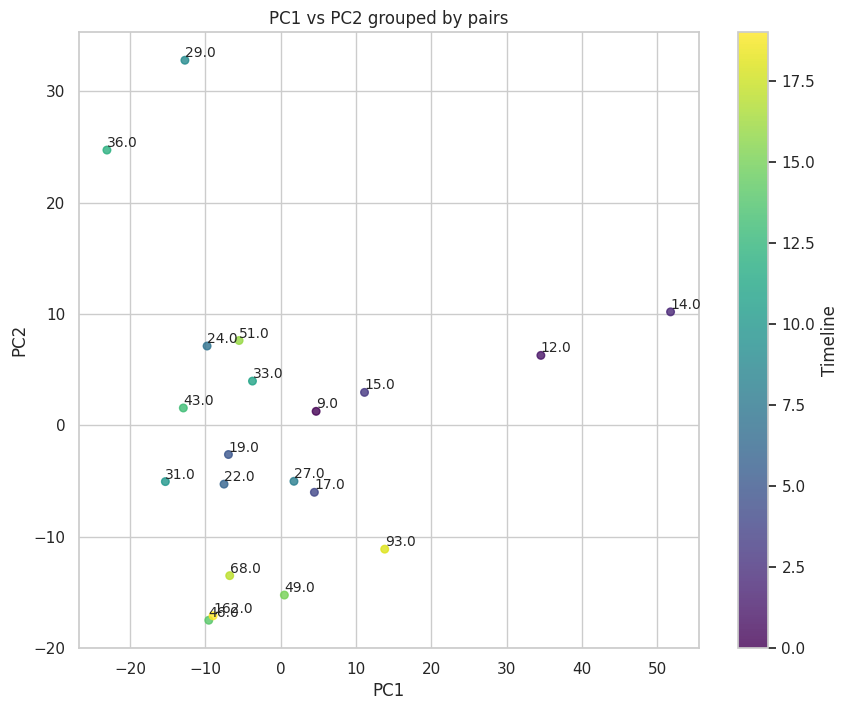

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create pair-based labels: [0,1] -> 0, [2,3] -> 1, [4,5] -> 2, ...
df_pca = df_pca.copy()
df_pca['pair_type'] = np.arange(len(df_pca)) // 1

# 2D scatter of first two PCs
plt.figure(figsize=(10, 8))

plot_type = 'numeric'
labels = participants_gw.to_list()

if plot_type == 'numeric':
    plt.scatter(
        df_pca['PC1'], df_pca['PC2'],
        c=df_pca['pair_type'],
        cmap='viridis',
        s=30,
        alpha=0.8
    )
    plt.colorbar(label='Timeline') 
    # add numeric labels to each point
    for i, (x, y, lab) in enumerate(zip(df_pca['PC1'], df_pca['PC2'], labels)):
        plt.text(x, y, str(lab), fontsize=10, ha='left', va='bottom')

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PC1 vs PC2 grouped by pairs')
    plt.grid(True)
    plt.show()
elif plot_type == 'gestation_week':
    print(labels)
    sc = plt.scatter(
        df_pca['PC1'], df_pca['PC2'],
        c=labels,
        cmap='viridis',
        s=30,
        alpha=0.8
    )

    # add numeric labels to each point
    for i, (x, y, lab) in enumerate(zip(df_pca['PC1'], df_pca['PC2'], labels)):
        plt.text(x, y, str(lab), fontsize=10, ha='left', va='bottom')

    plt.colorbar(sc, label='gestation week')
    
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Scatter with Labels')
    plt.show()


## PC1 - PC3: 3D Visualization

In [24]:
import numpy as np
import pandas as pd
import plotly.express as px

pair_unit = 1
# Create pair-based labels: [0,1] -> 0, [2,3] -> 1, [4,5] -> 2, ... when pair_unit == 2
df_pca = df_pca.copy()
df_pca['label'] = np.arange(len(df_pca)) // pair_unit
#df_pca['label'] = participants_gw.to_list()
# Interactive 3D scatter plot
fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='label',
    title='3D PCA Plot (PC1 vs PC2 vs PC3)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=6))
fig.show()

## Loading Analysis


Top 10 features for PC1:


,feature,loading
0,Feature_679,0.058091
1,Feature_311,0.057302
2,Feature_109,0.057209
3,Feature_576,-0.057105
4,Feature_650,-0.056969
5,Feature_482,0.056770
6,Feature_454,0.056695
7,Feature_106,0.056673
8,Feature_448,-0.056659
9,Feature_600,0.056576


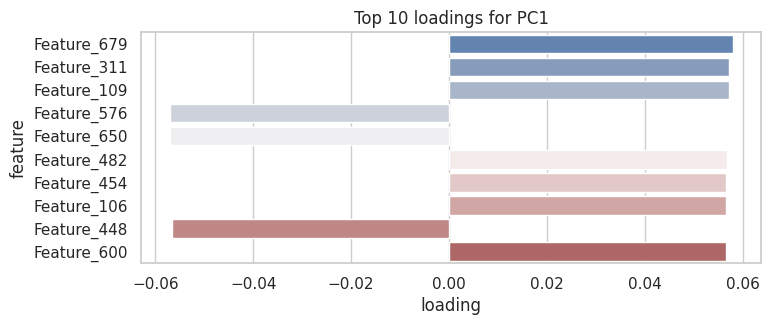


Top 10 features for PC2:


,feature,loading
0,Feature_579,-0.074983
1,Feature_746,0.074236
2,Feature_702,0.073983
3,Feature_130,-0.073961
4,Feature_354,0.073694
5,Feature_150,-0.073575
6,Feature_99,0.072418
7,Feature_510,0.071870
8,Feature_412,0.071523
9,Feature_286,0.071449


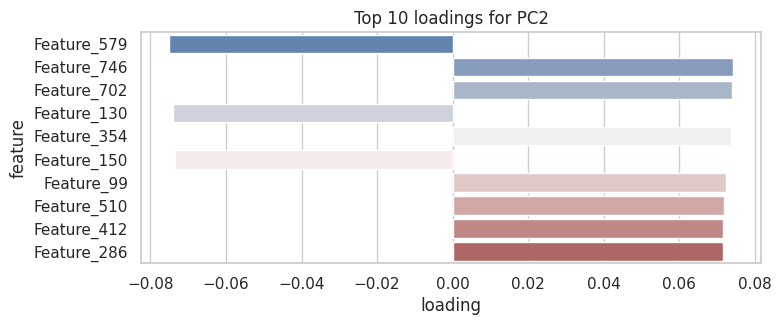


Top 10 features for PC3:


,feature,loading
0,Feature_56,-0.093676
1,Feature_677,-0.092797
2,Feature_202,0.090221
3,Feature_462,0.087919
4,Feature_470,0.087536
5,Feature_96,-0.086945
6,Feature_420,-0.085123
7,Feature_410,0.083628
8,Feature_290,0.083595
9,Feature_159,-0.083319


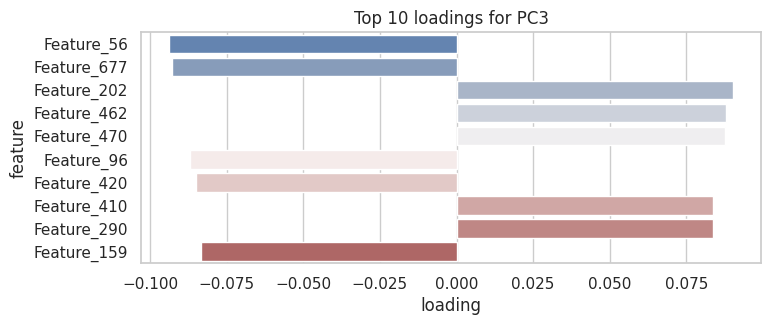


Top 10 features for PC4:


,feature,loading
0,Feature_758,-0.096726
1,Feature_451,-0.094194
2,Feature_371,0.091823
3,Feature_569,-0.091260
4,Feature_405,0.090915
5,Feature_722,0.089389
6,Feature_361,0.088324
7,Feature_292,-0.087800
8,Feature_463,-0.087129
9,Feature_755,-0.086876


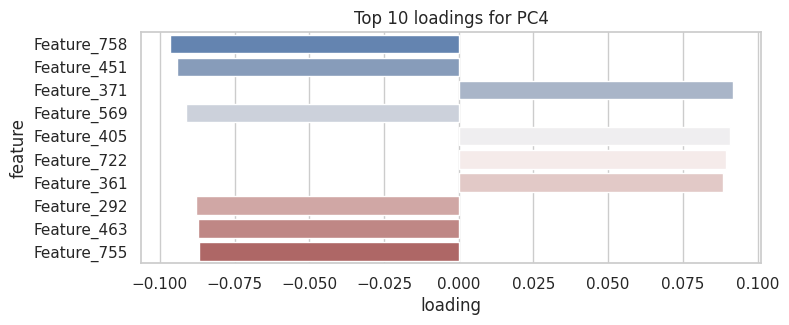


Top 10 features for PC5:


,feature,loading
0,Feature_418,0.122421
1,Feature_468,0.113387
2,Feature_599,0.111542
3,Feature_515,-0.109577
4,Feature_494,0.106670
5,Feature_132,0.105654
6,Feature_123,-0.104728
7,Feature_167,0.101008
8,Feature_745,-0.100160
9,Feature_372,0.098653


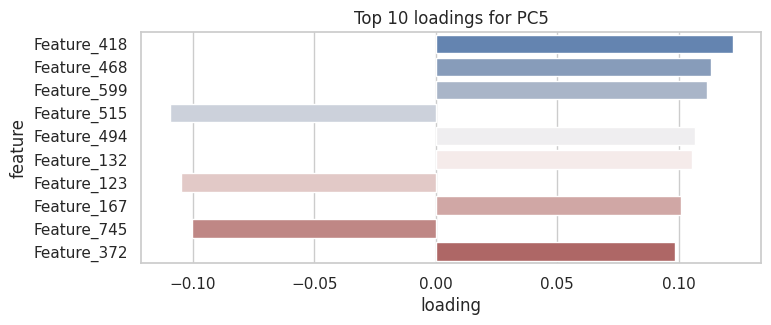


Top 10 features for PC6:


,feature,loading
0,Feature_739,0.131119
1,Feature_59,0.123772
2,Feature_224,0.110730
3,Feature_489,0.107864
4,Feature_57,-0.107842
5,Feature_691,0.107798
6,Feature_256,0.104699
7,Feature_753,0.101954
8,Feature_117,-0.098338
9,Feature_617,-0.097926


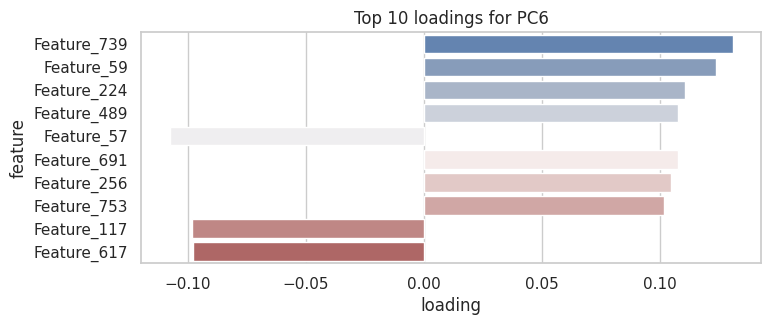


Top 10 features for PC7:


,feature,loading
0,Feature_191,-0.155279
1,Feature_23,-0.136663
2,Feature_430,-0.133930
3,Feature_408,0.126462
4,Feature_531,-0.124074
5,Feature_289,0.123555
6,Feature_333,-0.123118
7,Feature_584,-0.119605
8,Feature_331,-0.117453
9,Feature_692,0.113481


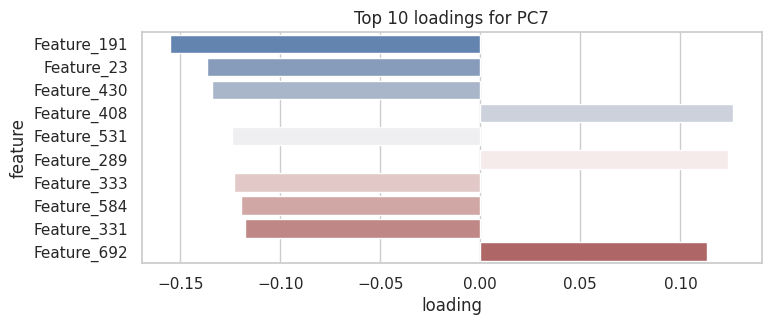


Top 10 features for PC8:


,feature,loading
0,Feature_658,0.132384
1,Feature_334,-0.125293
2,Feature_515,-0.120947
3,Feature_590,-0.119543
4,Feature_506,-0.117113
5,Feature_619,-0.111904
6,Feature_474,-0.109328
7,Feature_285,-0.103306
8,Feature_142,-0.102028
9,Feature_53,0.101765


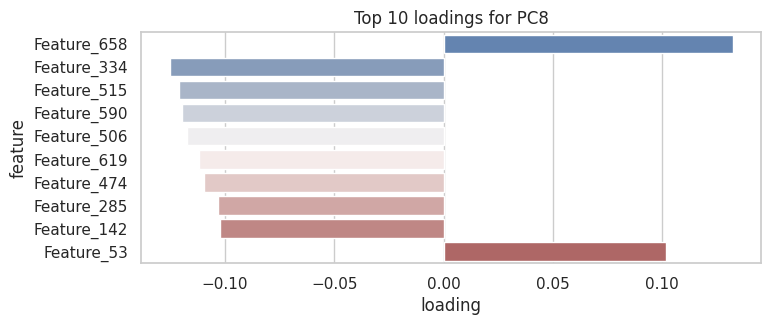


Top 10 features for PC9:


,feature,loading
0,Feature_319,0.150258
1,Feature_647,0.141120
2,Feature_496,-0.138629
3,Feature_21,0.134002
4,Feature_642,-0.127166
5,Feature_718,-0.119317
6,Feature_175,-0.116515
7,Feature_372,0.114901
8,Feature_33,0.111479
9,Feature_428,0.111281


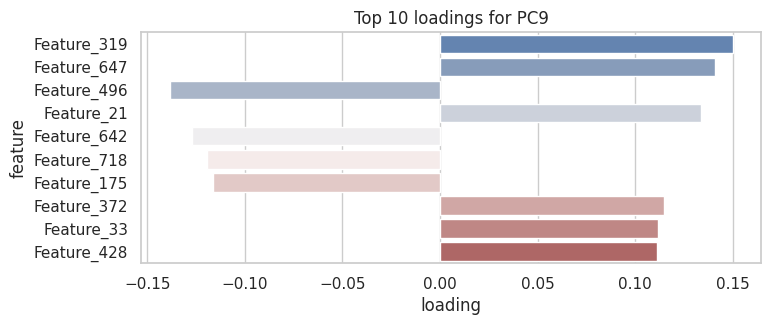


Top 10 features for PC10:


,feature,loading
0,Feature_590,-0.161374
1,Feature_604,-0.151995
2,Feature_756,0.140616
3,Feature_324,-0.140510
4,Feature_178,0.137020
5,Feature_658,-0.135481
6,Feature_142,-0.131553
7,Feature_533,0.118503
8,Feature_381,-0.114033
9,Feature_469,-0.108526


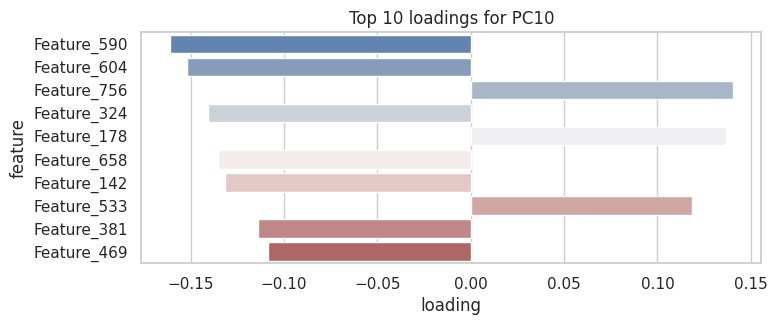

In [25]:
# Top contributing features per principal component
loadings = pca.components_  # shape (n_components, n_features)
abs_loadings = np.abs(loadings)
for i in range(loadings.shape[0]):
    comp = loadings[i]
    abs_comp = abs_loadings[i]
    top_idx = np.argsort(-abs_comp)[:top_k]
    top_features = [feature_cols[j] for j in top_idx]
    top_vals = comp[top_idx]
    df_load = pd.DataFrame({'feature': top_features, 'loading': top_vals})
    print(f"\nTop {top_k} features for PC{i+1}:")
    display(df_load)
    plt.figure(figsize=(8,3))
    sns.barplot(x='loading', y='feature', data=df_load, palette='vlag')
    plt.title(f'Top {top_k} loadings for PC{i+1}')
    plt.show()


/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecate

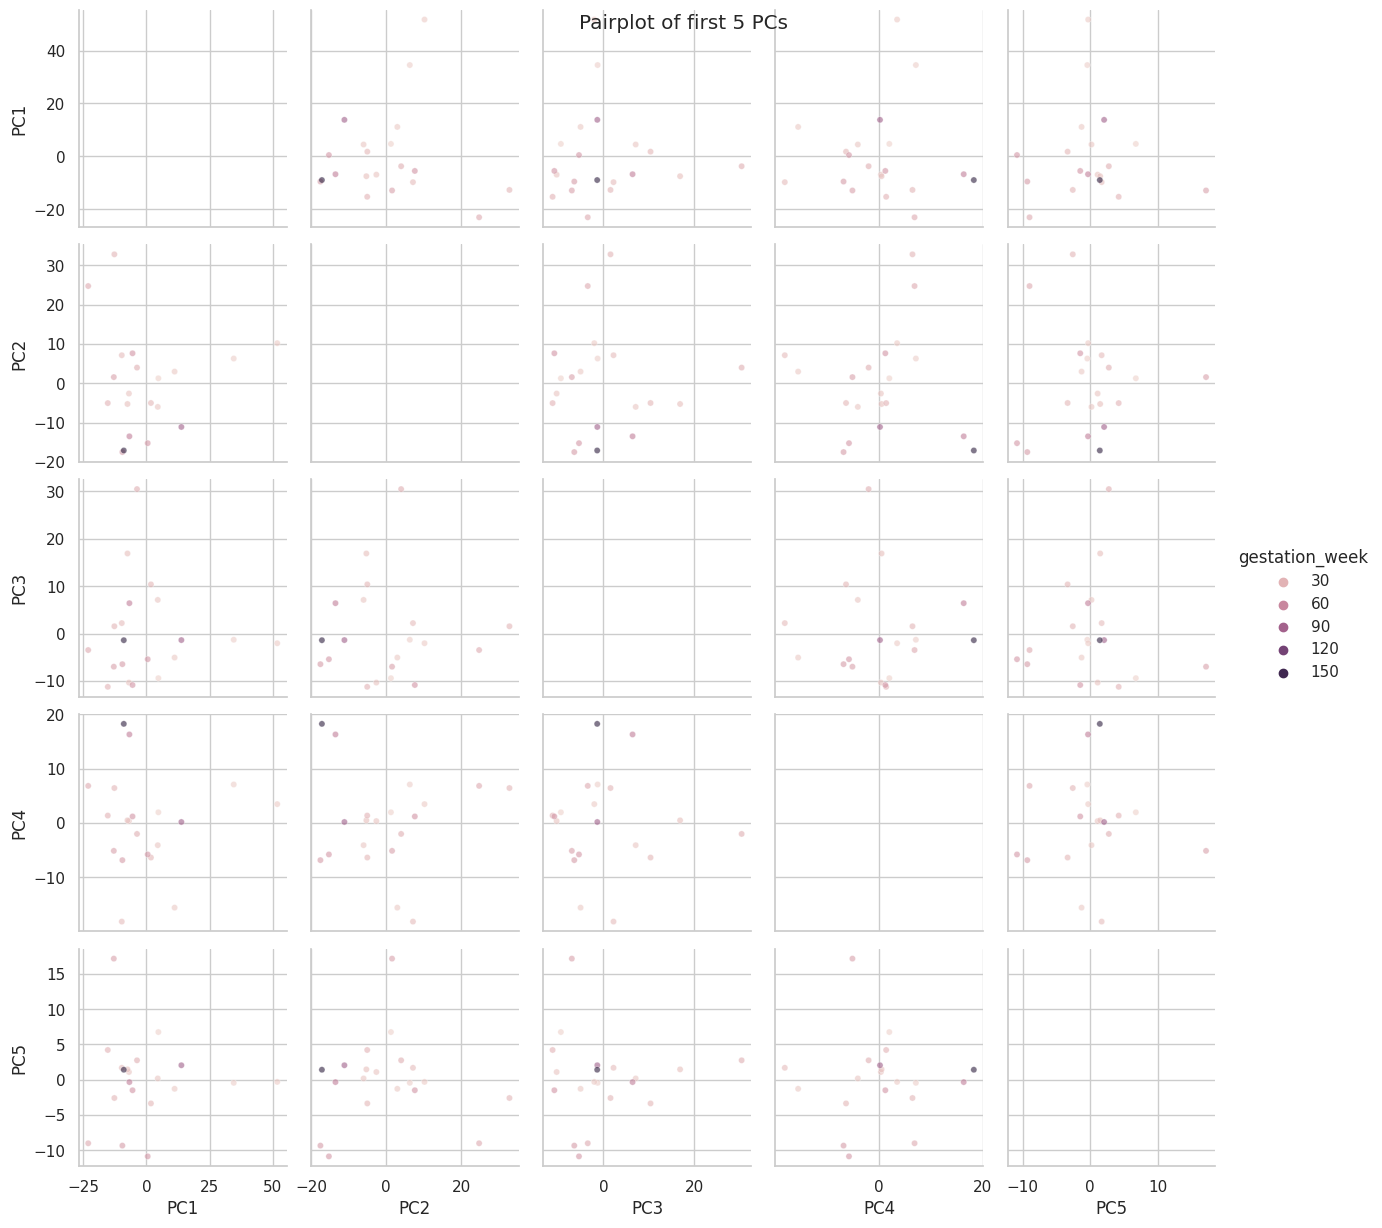

In [26]:
# Pairplot of first few PCs (sampled if large)
pc_for_pairplot = min(5, X_pca.shape[1])
vars_to_plot = [f'PC{i+1}' for i in range(pc_for_pairplot)]
df_pair = df_pca[vars_to_plot + ([label_col] if label_col else [])]
if sample_for_pairplot and len(df_pair) > sample_for_pairplot:
    df_pair_sample = df_pair.sample(sample_for_pairplot, random_state=42)
else:
    df_pair_sample = df_pair

if label_col:
    sns.pairplot(df_pair_sample, vars=vars_to_plot, hue=label_col, plot_kws={'s':20, 'alpha':0.6})
else:
    sns.pairplot(df_pair_sample, vars=vars_to_plot)
plt.suptitle('Pairplot of first %d PCs' % pc_for_pairplot)
plt.show()


In [27]:
# Optionally save PCA-transformed data
if output_reduced_csv:
    df_pca.to_csv(output_reduced_csv, index=False)
    print('Saved PCA-transformed data to', output_reduced_csv)


Saved PCA-transformed data to features_pca.csv


## Simple Analysis

#### Linear Regression

Linear Regression on first 10 PCs
R^2   : 0.0022
RMSE  : 7.7815
MAE   : 6.1776

Coefficients:
     PC  Coefficient
0   PC1    -0.078892
1   PC2    -0.113257
2   PC3    -0.031653
3   PC4     0.301732
4   PC5    -0.019208
5   PC6    -0.323133
6   PC7     0.467538
7   PC8     0.086719
8   PC9     0.651935
9  PC10     0.116449


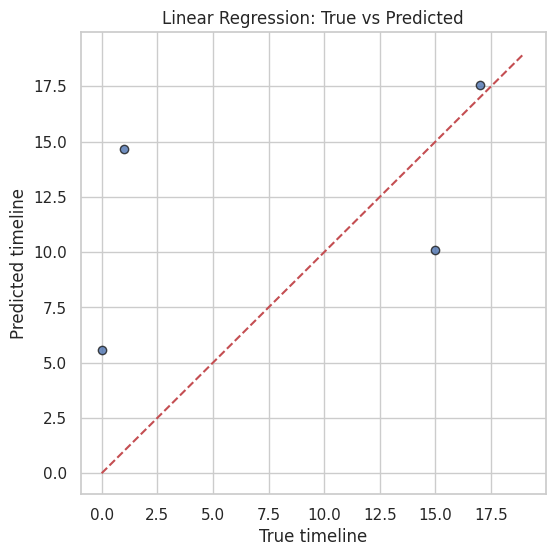

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Use first 10 PCs
X_lr = df_pca[[f'PC{i+1}' for i in range(10)]].values

# Choose target
y = np.arange(len(participants_gw.to_list()))#np.array(participants_gw.to_list())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Show coefficients
coef_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(10)],
    'Coefficient': lr.coef_
})
print("\nCoefficients:")
print(coef_df)

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("Linear Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

Linear Regression on first 10 PCs
R^2   : -1.1105
RMSE  : 6.9504
MAE   : 6.6063

Coefficients:
     PC  Coefficient
0   PC1    -0.085050
1   PC2     0.129100
2   PC3     0.004220
3   PC4    -0.205895
4   PC5     0.209537
5   PC6     0.406900
6   PC7     0.609784
7   PC8    -0.291706
8   PC9    -0.307446
9  PC10     0.057823


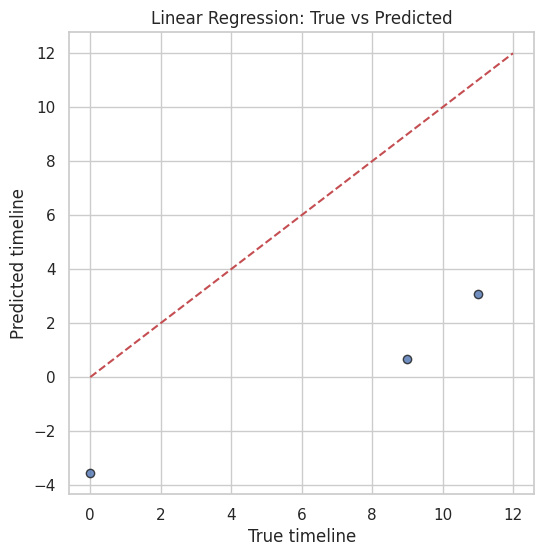

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Use first 10 PCs
X_lr = df_pca[[f'PC{i+1}' for i in range(10)]].values[:-7]

# Choose target
y = np.arange(len(participants_gw.to_list()))[:-7]#np.array(participants_gw.to_list())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Show coefficients
coef_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(10)],
    'Coefficient': lr.coef_
})
print("\nCoefficients:")
print(coef_df)

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("Linear Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

Linear Regression on first 10 PCs
R^2   : -47.8049
RMSE  : 3.4930
MAE   : 3.1502

Coefficients:
     PC  Coefficient
0   PC1     0.027921
1   PC2    -0.089763
2   PC3    -0.156281
3   PC4     0.116868
4   PC5     0.139171
5   PC6     0.049080
6   PC7    -0.007619
7   PC8     0.006832
8   PC9     0.064135
9  PC10    -0.047890


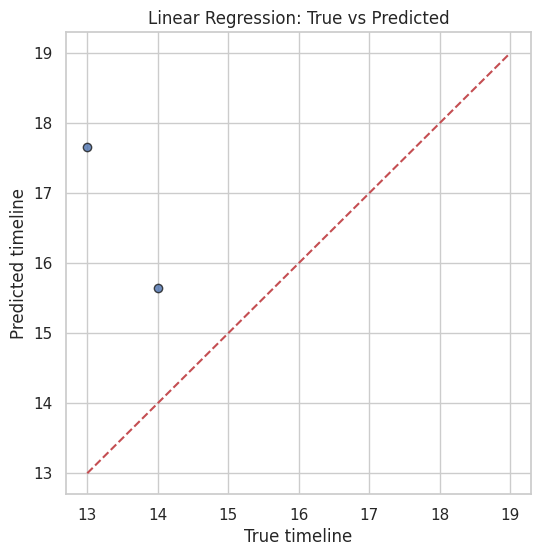

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Use first 10 PCs
X_lr = df_pca[[f'PC{i+1}' for i in range(10)]].values[-7:]

# Choose target
y = np.arange(len(participants_gw.to_list()))[-7:]#np.array(participants_gw.to_list())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Show coefficients
coef_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(10)],
    'Coefficient': lr.coef_
})
print("\nCoefficients:")
print(coef_df)

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("Linear Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

#### KNN

KNN Regression on first 10 PCs
R^2   : 0.2338
RMSE  : 6.8191
MAE   : 5.5000


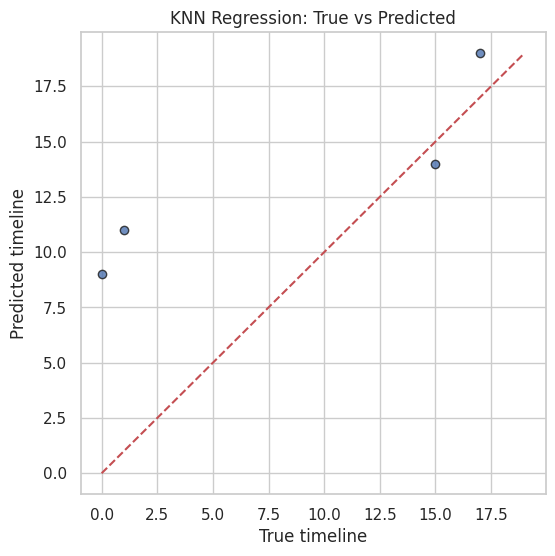

In [63]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use first 10 PCs
X_knn = df_pca[[f'PC{i+1}' for i in range(10)]].values

y = np.arange(len(participants_gw.to_list()))#np.array(participants_gw.to_list())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_knn, y, test_size=0.2, random_state=42
)

# KNN is distance-based, so scaling is important
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

# Fit KNN regressor
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("KNN Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("KNN Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

KNN Regression on first 10 PCs
R^2   : -2.0000
RMSE  : 6.6833
MAE   : 6.0000


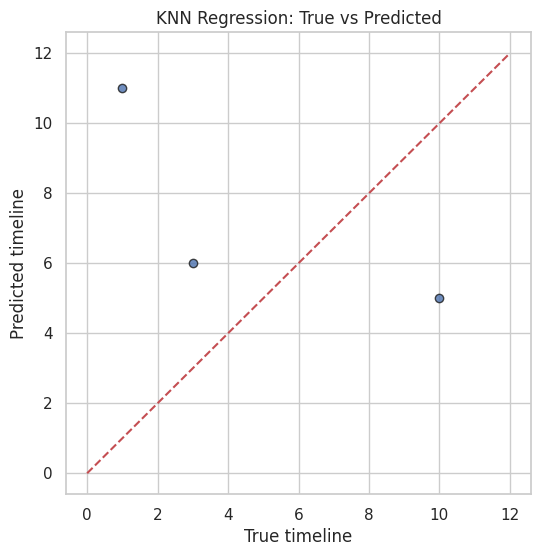

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use first 10 PCs
X_knn = df_pca[[f'PC{i+1}' for i in range(10)]].values[:-7]

y = np.arange(len(participants_gw.to_list()))[:-7]#np.array(participants_gw.to_list())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_knn, y, test_size=0.2, random_state=42
)

# KNN is distance-based, so scaling is important
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

# Fit KNN regressor
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("KNN Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("KNN Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

KNN Regression on first 10 PCs
R^2   : -19.0000
RMSE  : 2.2361
MAE   : 2.0000


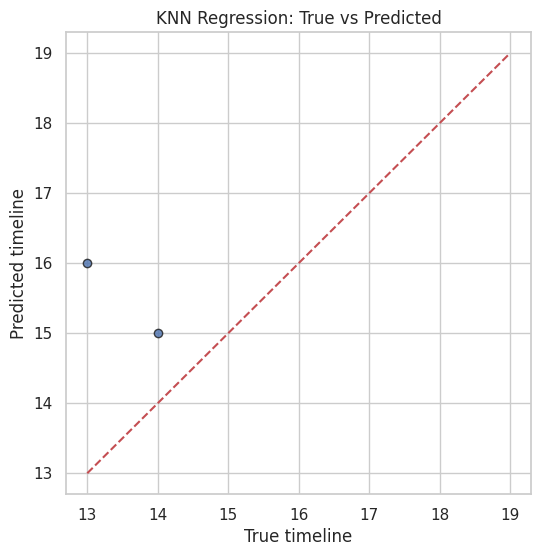

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use first 10 PCs
X_knn = df_pca[[f'PC{i+1}' for i in range(10)]].values[-7:]

y = np.arange(len(participants_gw.to_list()))[-7:]#np.array(participants_gw.to_list())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_knn, y, test_size=0.2, random_state=42
)

# KNN is distance-based, so scaling is important
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

# Fit KNN regressor
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("KNN Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("KNN Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

In [27]:
np.array(participants_gw.to_list())[:-7]

array([ 9., 12., 14., 15., 17., 19., 22., 24., 27., 29., 31., 33., 36.])

KNN Regression on first 10 PCs
R^2   : 0.7203
RMSE  : 3.0496
MAE   : 1.1000


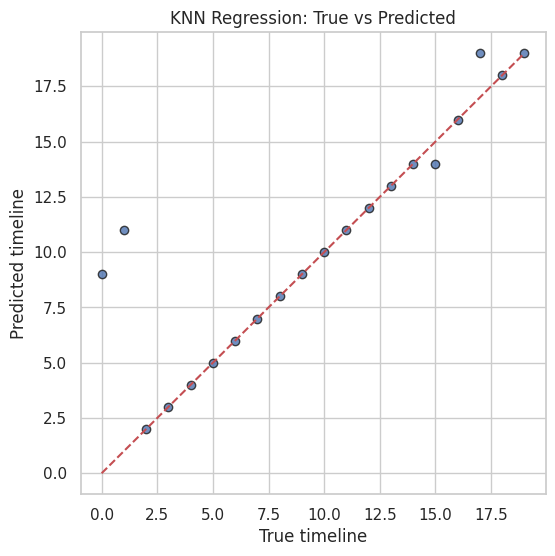

In [30]:
# Predict
X = scaler_knn.transform(X_lr)
y_pred = knn.predict(X)

# Evaluate
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("KNN Regression on first 10 PCs")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.8, edgecolor='k')
plt.xlabel("True timeline")
plt.ylabel("Predicted timeline")
plt.title("KNN Regression: True vs Predicted")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

#### K-means

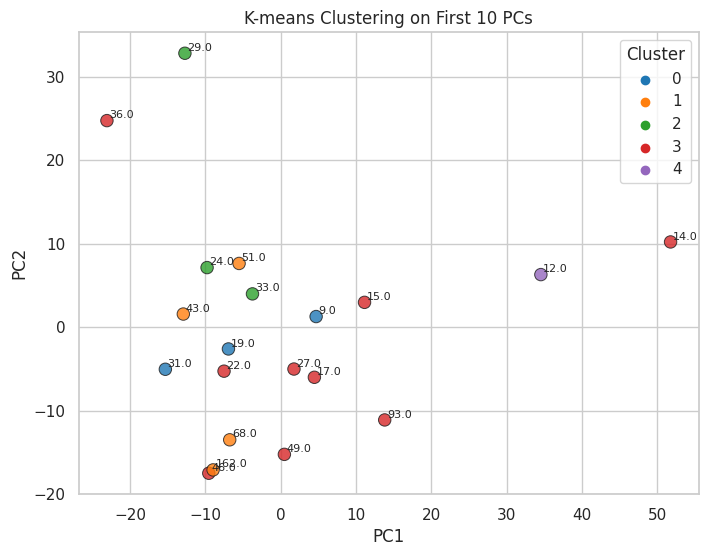

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ----------------------------
# Prepare data
# ----------------------------
n_pcs = 10
pc_cols = [f'PC{i+1}' for i in range(n_pcs)] #+ ['gestation_week']

if 'gestation_week' not in df_pca.columns:
    raise ValueError("gestation_week not found in df_pca")

# Feature matrix from first 10 PCs
X_kmeans = df_pca[pc_cols].values

# Standardize before KMeans
scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

# ----------------------------
# Run KMeans
# ----------------------------
n_clusters = 5   # change this if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_kmeans_scaled)

# Add cluster labels to dataframe
df_km = df_pca.copy()
df_km['cluster'] = cluster_labels

# ----------------------------
# Plot in 2D using PC1 vs PC2
# ----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_km,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    s=80,
    edgecolor='k',
    alpha=0.8
)

# Label each point with gestation_week
for i, row in df_km.iterrows():
    plt.text(
        row['PC1'] + 0.3,
        row['PC2'] + 0.3,
        str(row['gestation_week']),
        fontsize=8
    )

plt.title('K-means Clustering on First 10 PCs')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [32]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Prepare data
# ----------------------------
n_pcs = 10
pc_cols = [f'PC{i+1}' for i in range(n_pcs)]+ ['gestation_week']

if 'gestation_week' not in df_pca.columns:
    raise ValueError("gestation_week not found in df_pca")

X_kmeans = df_pca[pc_cols].values

# Standardize before KMeans
scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

# ----------------------------
# Run KMeans
# ----------------------------
n_clusters = 4   # change if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_kmeans_scaled)

# Add cluster labels
df_km = df_pca.copy()
df_km['cluster'] = cluster_labels

# ----------------------------
# Find point closest to each cluster center
# ----------------------------
closest_points = []

for cluster_id in range(n_clusters):
    cluster_idx = np.where(cluster_labels == cluster_id)[0]
    cluster_points = X_kmeans_scaled[cluster_idx]
    center = kmeans.cluster_centers_[cluster_id]

    # Euclidean distance to center
    distances = np.linalg.norm(cluster_points - center, axis=1)
    closest_local_idx = np.argmin(distances)
    closest_global_idx = cluster_idx[closest_local_idx]

    point_info = df_km.iloc[closest_global_idx].to_dict()
    point_info['distance_to_center'] = distances[closest_local_idx]
    closest_points.append(point_info)

    print(f"\nCluster {cluster_id}:")
    print(f"  Closest sample index: {closest_global_idx}")
    print(f"  Gestation week: {point_info['gestation_week']}")
    print(f"  Distance to center: {point_info['distance_to_center']:.4f}")
    print(f"  PC values: {[point_info[c] for c in pc_cols]}")

# Optional: store in a dataframe
closest_df = pd.DataFrame(closest_points)
print("\nClosest points to each cluster center:")
print(closest_df[['cluster', 'gestation_week', 'distance_to_center'] + pc_cols])


Cluster 0:
  Closest sample index: 7
  Gestation week: 24.0
  Distance to center: 2.5380
  PC values: [-9.760375912458608, 7.121389023114244, 2.2238497111493167, -18.156180330639117, 1.698678238665382, -3.670108974957954, -0.9489042667763634, -0.11809884227779954, 1.8519388818998141, 7.583557678130478, 24.0]

Cluster 1:
  Closest sample index: 10
  Gestation week: 31.0
  Distance to center: 2.2450
  PC values: [-15.296147529057482, -5.053541548443108, -11.221629323363103, 1.3658317751833007, 4.223446464182252, 7.40830459834717, 3.5328404160754476, 1.7012970226594133, -2.4038600520648212, 1.1803197755088803, 31.0]

Cluster 2:
  Closest sample index: 17
  Gestation week: 68.0
  Distance to center: 1.4439
  PC values: [-6.756009937870388, -13.50015382516323, 6.42895419034332, 16.3079101951474, -0.32272061516551603, -3.2125829378564412, -2.045629496011619, -2.758056782892052, 0.8162639541562989, 1.392628937075901, 68.0]

Cluster 3:
  Closest sample index: 3
  Gestation week: 15.0
  Distan

In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# ----------------------------
# Helper: build data
# ----------------------------
def get_regression_data(df_pca, n_pcs=10, target_col='gestation_week'):
    pc_cols = [f'PC{i+1}' for i in range(n_pcs)]
    missing = [c for c in pc_cols if c not in df_pca.columns]
    if missing:
        raise ValueError(f"Missing PCA columns: {missing}")

    if target_col not in df_pca.columns:
        raise ValueError(f"Target column '{target_col}' not found in df_pca.")

    X = df_pca[pc_cols].values
    y = df_pca[target_col].values

    print(f"Using target label: {target_col}")
    print(f"Using features: {pc_cols}")
    print(f"Number of samples: {len(df_pca)}")
    return X, y, pc_cols, target_col


# ----------------------------
# CV evaluation function
# ----------------------------
def evaluate_model_cv(model, X, y, model_name="model", n_splits=5, random_state=42):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    scoring = {
        "r2": "r2",
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error"
    }

    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    r2_scores = results["test_r2"]
    rmse_scores = -results["test_neg_rmse"]
    mae_scores = -results["test_neg_mae"]

    print(f"\n=== {model_name} ===")
    print(f"R2   : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"RMSE : {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    print(f"MAE  : {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")

    return {
        "model": model_name,
        "r2_mean": r2_scores.mean(),
        "r2_std": r2_scores.std(),
        "rmse_mean": rmse_scores.mean(),
        "rmse_std": rmse_scores.std(),
        "mae_mean": mae_scores.mean(),
        "mae_std": mae_scores.std(),
    }


# ----------------------------
# Main comparison function
# ----------------------------
def compare_lr_knn_cv(df_pca, n_pcs=10, target_col='gestation_week', n_splits=5):
    X, y, pc_cols, used_target = get_regression_data(df_pca, n_pcs=n_pcs, target_col=target_col)

    # Linear Regression
    lr_model = LinearRegression()
    lr_results = evaluate_model_cv(
        lr_model, X, y,
        model_name="Linear Regression",
        n_splits=n_splits
    )

    # KNN Regression needs scaling, so use a pipeline
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=3))
    ])
    knn_results = evaluate_model_cv(
        knn_model, X, y,
        model_name="KNN Regression (k=3)",
        n_splits=n_splits
    )

    summary = pd.DataFrame([lr_results, knn_results])
    return summary


# ----------------------------
# Run it
# ----------------------------
summary_df = compare_lr_knn_cv(df_pca, n_pcs=10, target_col='gestation_week', n_splits=5)
print("\nSummary:")
print(summary_df)

Using target label: gestation_week
Using features: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']
Number of samples: 20

=== Linear Regression ===
R2   : -3.8917 ± 4.8685
RMSE : 33.3102 ± 11.9546
MAE  : 29.2610 ± 12.0591

=== KNN Regression (k=3) ===
R2   : -1.8469 ± 3.1821
RMSE : 28.7426 ± 12.8181
MAE  : 22.4833 ± 7.3059

Summary:
                  model   r2_mean    r2_std  rmse_mean   rmse_std   mae_mean  \
0     Linear Regression -3.891716  4.868473  33.310190  11.954644  29.260961   
1  KNN Regression (k=3) -1.846920  3.182109  28.742568  12.818099  22.483333   

     mae_std  
0  12.059101  
1   7.305896  
